In [2]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [3]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

In [4]:
import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

In [5]:
import experiment_utils
from main import *

In [6]:
import main
argd = main.Args()


argd.n_iters = 50000
argd.log_every = 10000

args_all = []
seeds_all = range(5)
dts_all = [1, 2, 4, 8, 16, 32, 64, 128]
gol_params_all = [ 6152, 242251, 7291, 7787, 55871, 15923]
# gol_params_all = [2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923, 2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            args = copy.deepcopy(argd)
            args.data.gol_params = gol_params
            args.seed = seed
            args.data.dt = dt
            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params={gol_params}_dt={dt}_seed={seed}"
            args_all.append(args)
            print(args)
experiment_utils.create_commands(args_all, prefix="python main.py", out_file="science_scripts/main.sh");

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=1))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=2_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=2))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=4_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, 

In [7]:
# import linear_probe
# argd = linear_probe.LinearProbeArgs()

# argd.n_iters = 1000

# lp_args_all = []
# for args in args_all:
#     for ablate_features in ["none", "random", "zeros"]:
#     # for ablate_features in ["random"]:
#         lp_args = copy.deepcopy(argd)
#         lp_args.seed = args.seed
#         lp_args.load_dir = args.save_dir
#         lp_args.save_dir = f"{args.save_dir}_lp_{ablate_features}"
#         lp_args.ablate_features = ablate_features
#         lp_args_all.append(lp_args)
#         print(lp_args)

# # experiment_utils.create_commands(lp_args_all, prefix="python linear_probe.py", out_file="science_scripts/linear_probe.sh");

In [8]:
import linear_probe
argd = linear_probe.LinearProbeArgs()

argd.n_iters = 1000

lp_args_all = []
for args in args_all:
    for ablate_features in ["none", "random"]:
        for target in ["x0", "x1"]:
            lp_args = copy.deepcopy(argd)
            lp_args.seed = args.seed
            lp_args.load_dir = args.save_dir
            lp_args.save_dir = f"{args.save_dir}_lp_{ablate_features}_{target}"
            lp_args.ablate_features = ablate_features
            lp_args.target = target
            lp_args_all.append(lp_args)
            print(lp_args)
experiment_utils.create_commands(lp_args_all, prefix="python linear_probe.py", out_file="science_scripts/linear_probe.sh");

LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_none_x0', n_iters=1000, ablate_features='none', target='x0')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_none_x1', n_iters=1000, ablate_features='none', target='x1')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_random_x0', n_iters=1000, ablate_features='random', target='x0')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_random_x1', n_iters=1000, ablate_

In [9]:
pd.DataFrame([experiment_utils.dataclass_to_flat_dict(args) for args in args_all])

,seed,save_dir,n_iters,log_every,model.layers,model.channels,model.out_channels,model.n_dts,opt.batch_size,opt.learning_rate,opt.weight_decay,opt.clip_grad_norm,data.gol_params,data.grid_size,data.t_start,data.t_end,data.dt
0,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,1
1,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,2
2,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,4
3,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,8
4,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,8
236,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,16
237,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,32
238,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,64


In [10]:
df = []
for lp_args in lp_args_all:
    try:
        args = util.load_pkl(lp_args.load_dir, "args")
        final_loss = util.load_pkl(args.save_dir, "final_loss")
        metrics = util.load_pkl(lp_args.save_dir, "metrics")
        dfi = dict(dt=args.data.dt[0], seed=args.seed, gol_params=args.data.gol_params,
                   ablate_features=lp_args.ablate_features, target=lp_args.target, final_loss=final_loss)
        dfi = {**dfi, **metrics}
        df.append(dfi)
    except:
        pass
df = pd.DataFrame(df)

In [11]:
df

,dt,seed,gol_params,ablate_features,target,final_loss,score_train,score_test,mse_train,mse_test,cossim_train,cossim_test
0,1,0,6152,none,x0,4.547473e-14,0.283923,0.281220,0.000040,0.000040,0.98979396,0.9897014
1,1,0,6152,none,x1,4.547473e-14,0.281037,0.278497,0.000040,0.000040,0.98972845,0.98965317
2,1,0,6152,random,x0,4.547473e-14,0.321404,0.317939,0.000037,0.000038,0.99038595,0.9902851
3,1,0,6152,random,x1,4.547473e-14,0.309902,0.304639,0.000038,0.000039,0.99021477,0.9900964
4,2,0,6152,none,x0,7.241780e-11,0.271664,0.268111,0.000040,0.000041,0.989606,0.9894966
...,...,...,...,...,...,...,...,...,...,...,...,...
955,64,4,15923,random,x1,5.186090e-01,0.292970,0.291579,0.000077,0.000078,0.9801051,0.9799021
956,128,4,15923,none,x0,5.351270e-01,0.455008,0.452689,0.000052,0.000053,0.98648316,0.98640704
957,128,4,15923,none,x1,5.351270e-01,0.284834,0.281399,0.000084,0.000084,0.9782467,0.97811687
958,128,4,15923,random,x0,5.351270e-01,0.394643,0.394358,0.000059,0.000059,0.9848761,0.9848457


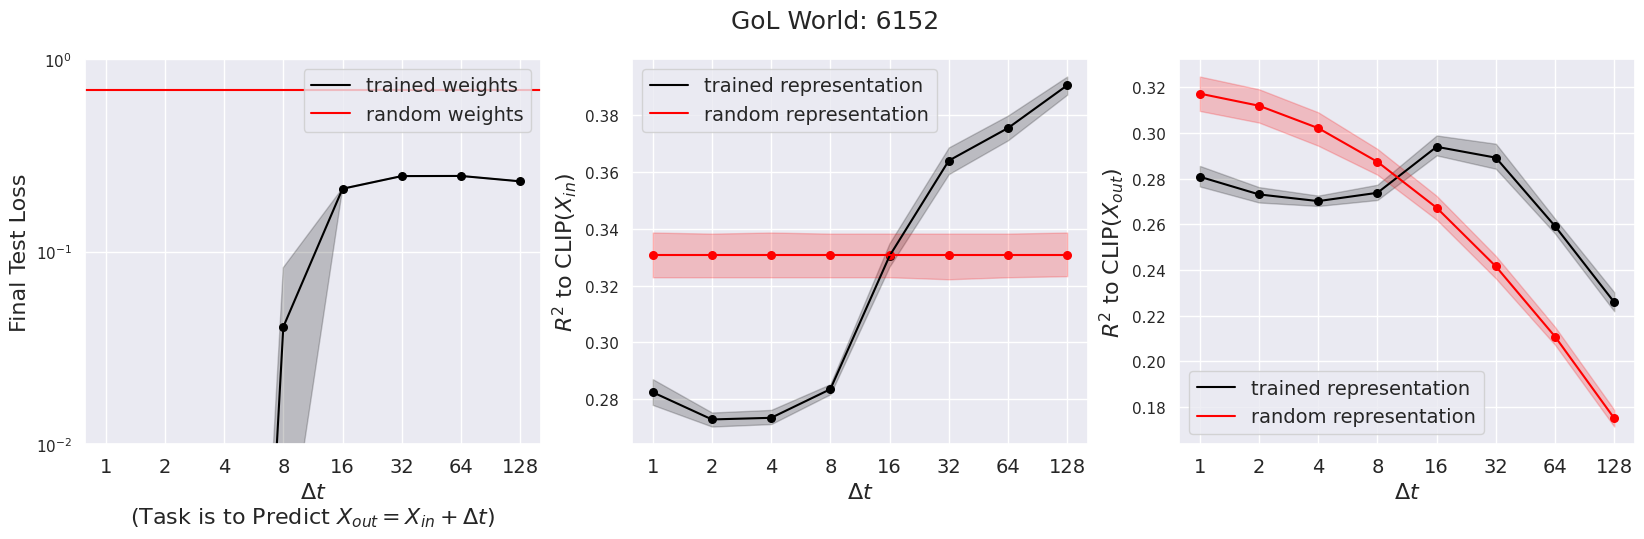

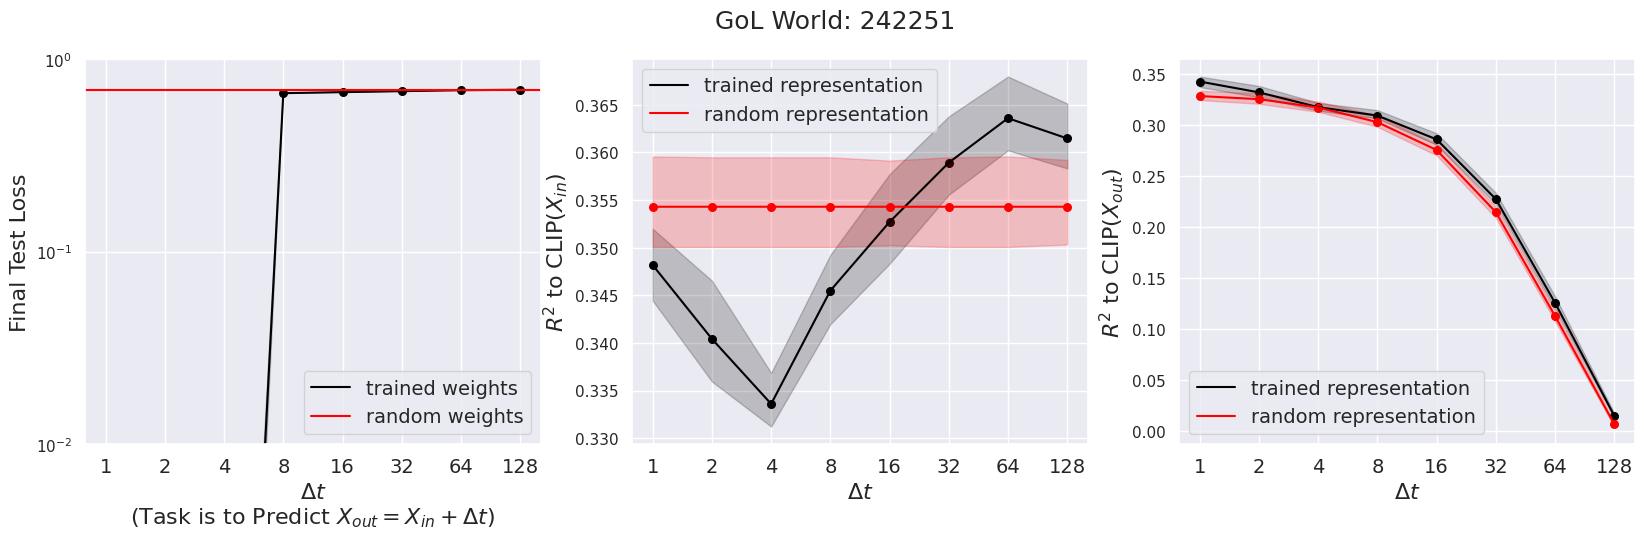

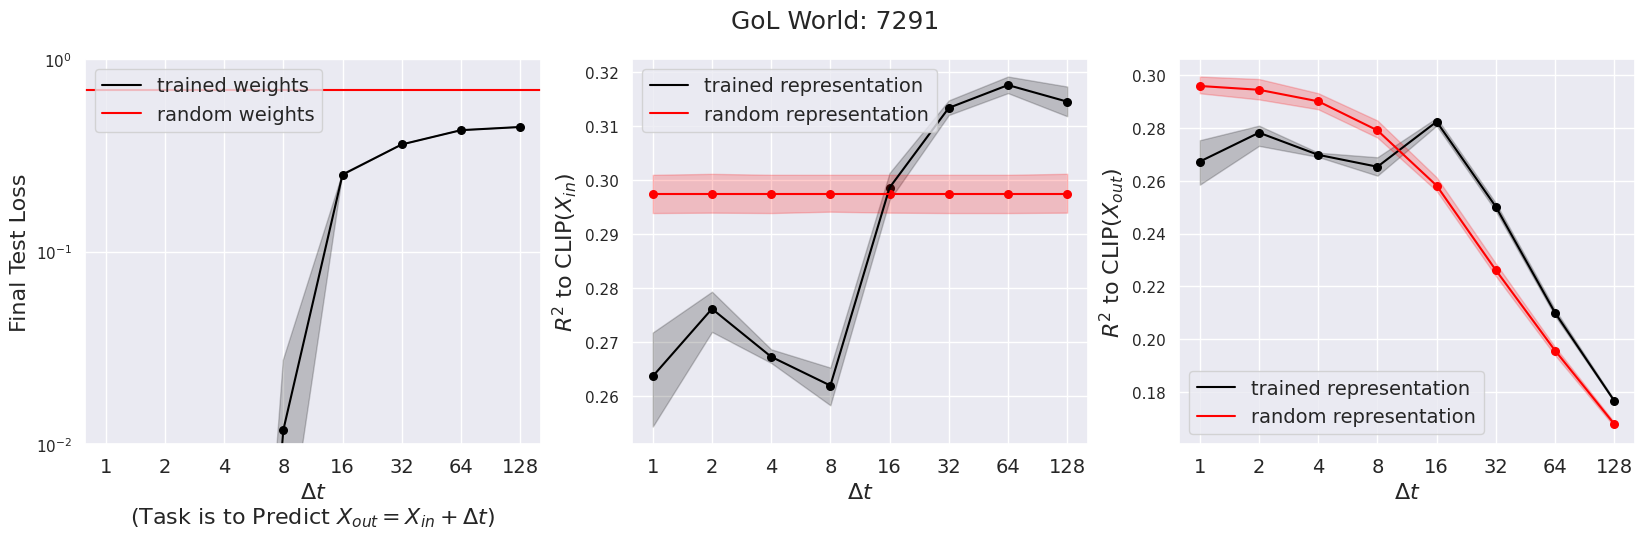

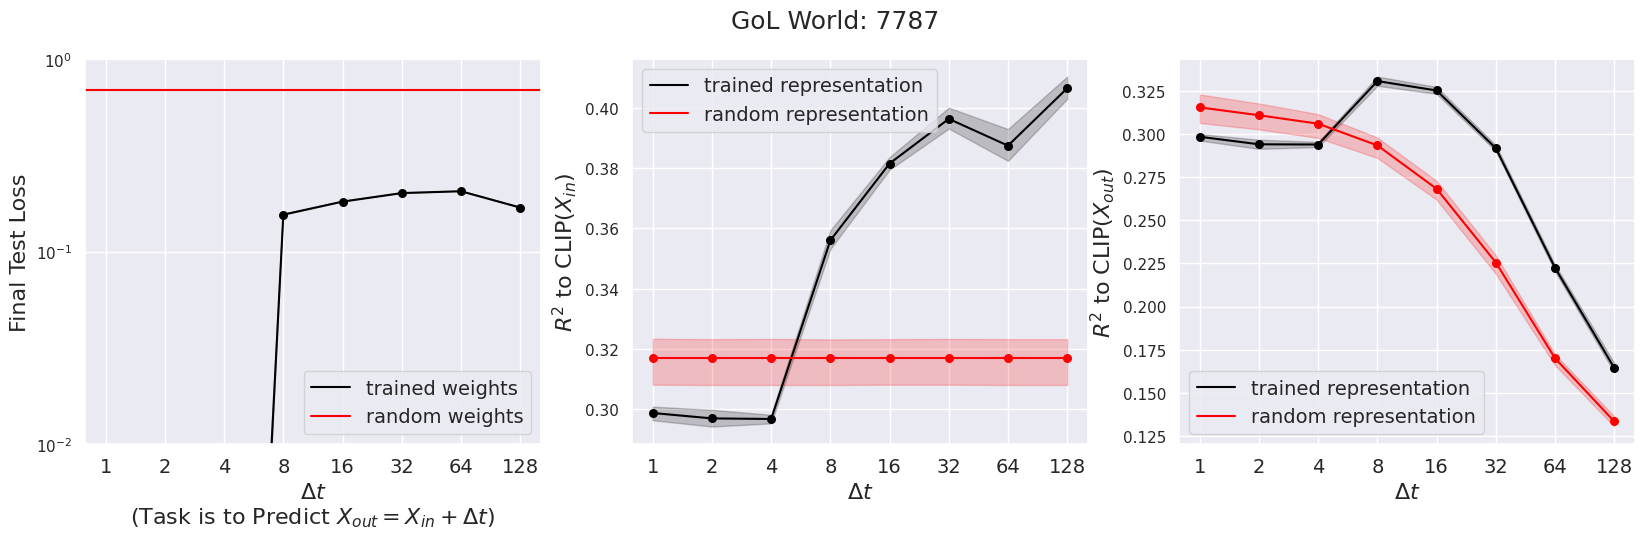

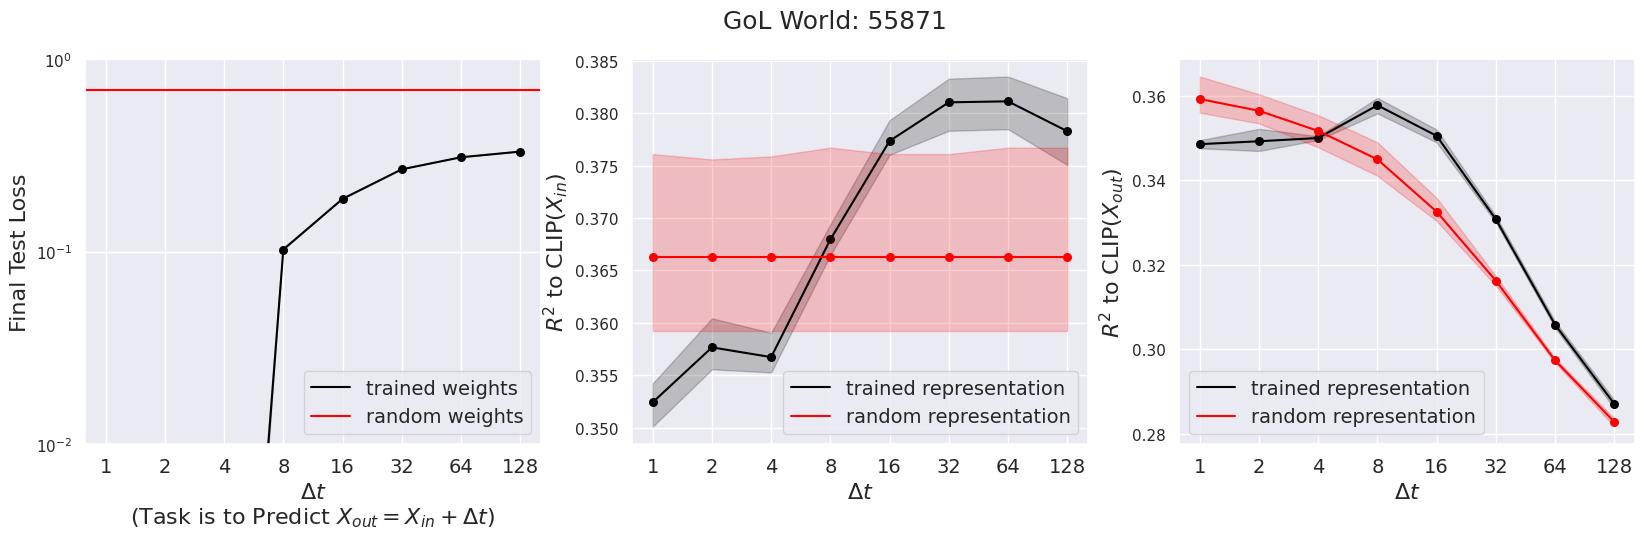

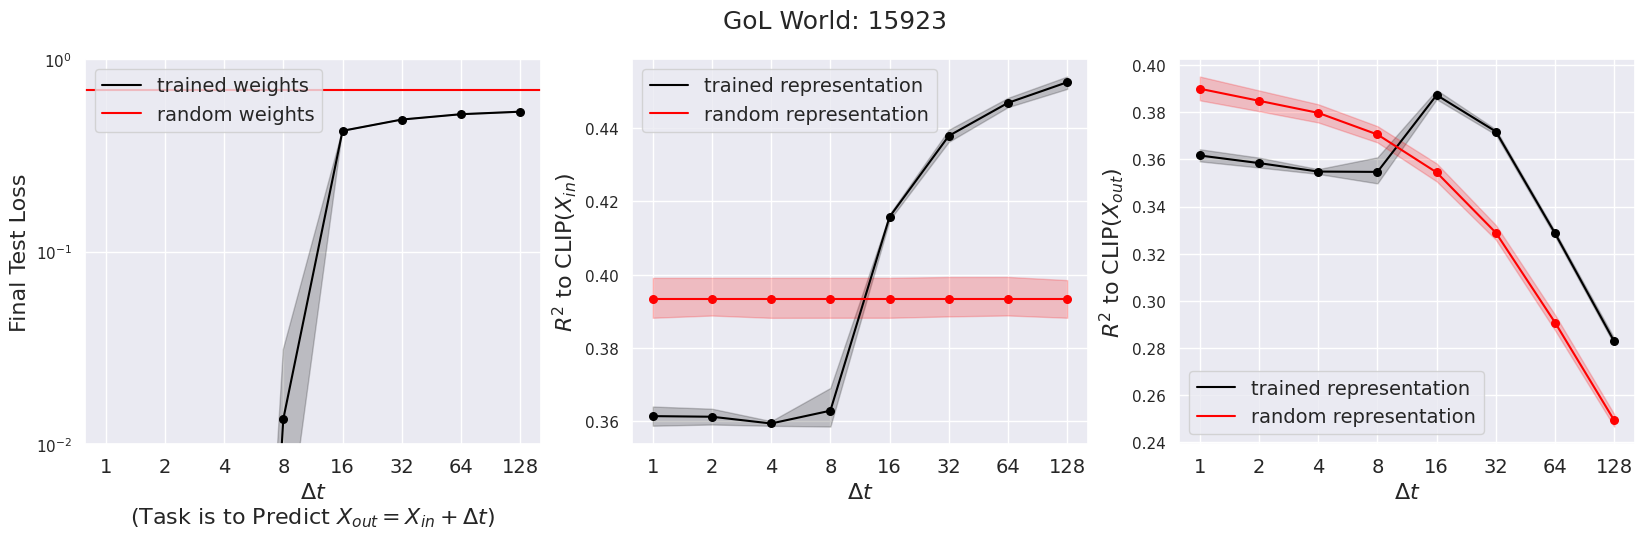

In [47]:
for gol_params in df.gol_params.unique():
    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x0")]
    b = df[(df.gol_params==gol_params) & (df.ablate_features=="random") & (df.target=="x0")]

    plt.figure(figsize=(20, 5))

    plt.subplot(131)
    sns.lineplot(data=a, x="dt", y="final_loss", color='black', label="trained weights")
    plt.scatter(a.dt.unique(), a.groupby("dt")['final_loss'].mean(), color='black', s=30, marker='o')

    plt.axhline(y=np.log(2), color='red', label="random weights")
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("Final Test Loss", fontsize=16)
    plt.xlabel("$\Delta t$\n(Task is to Predict $X_{out}=X_{in}+\Delta t$)", fontsize=16)
    plt.legend(fontsize=14)
    plt.yscale('log'); plt.ylim(1e-2, 1e0)

    plt.subplot(132)
    sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    sns.lineplot(data=b, x="dt", y="score_test", color='red', label="random representation")
    plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("$R^2$ to CLIP($X_{in}$)", fontsize=16)
    plt.xlabel("$\Delta t$", fontsize=16)
    plt.legend(fontsize=14)

    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x1")]
    b = df[(df.gol_params==gol_params) & (df.ablate_features=="random") & (df.target=="x1")]
    
    plt.subplot(133)
    sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    sns.lineplot(data=b, x="dt", y="score_test", color='red', ax=plt.gca(), label="random representation")
    plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("$R^2$ to CLIP($X_{out}$)", fontsize=16)
    plt.xlabel("$\Delta t$", fontsize=16)
    plt.legend(fontsize=14)

    plt.suptitle(f"GoL World: {gol_params}", fontsize=18)
    plt.show()
    # break

Args(seed=1, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=16_seed=1', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[16]))


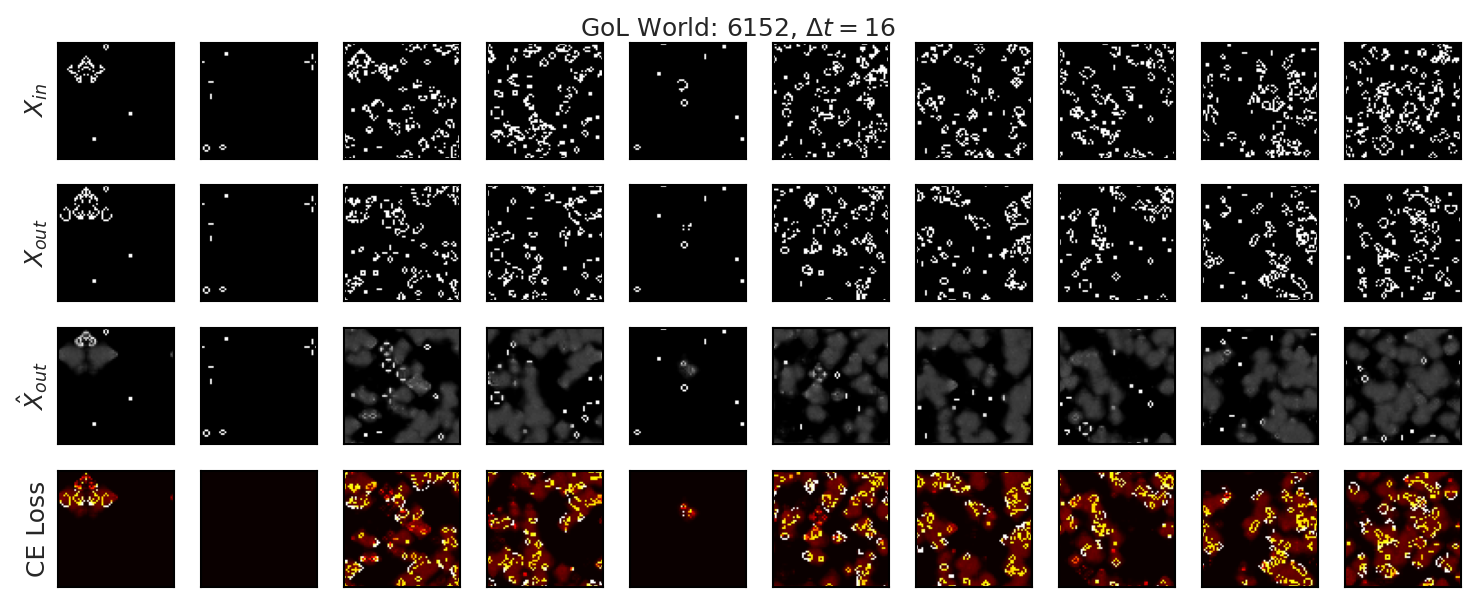

Args(seed=1, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=242251_dt=16_seed=1', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=242251, grid_size=64, t_start=32, t_end=64, dt=[16]))


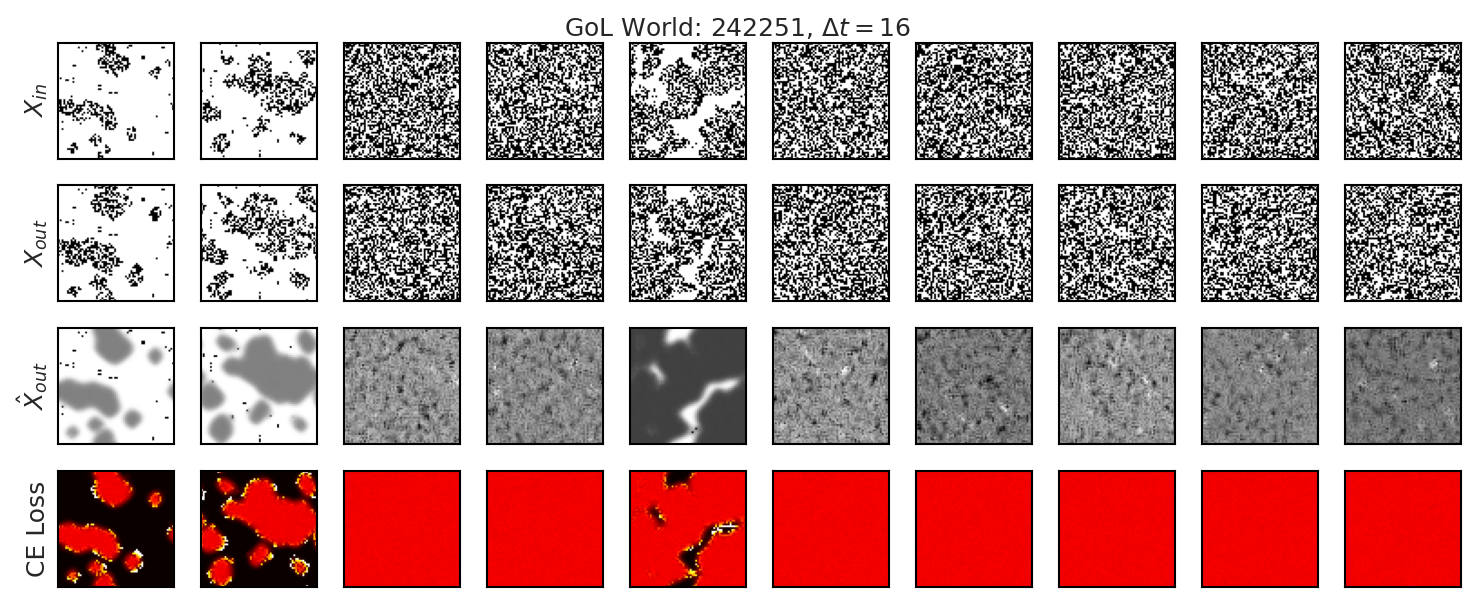

Args(seed=2, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=7291_dt=16_seed=2', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[16]))


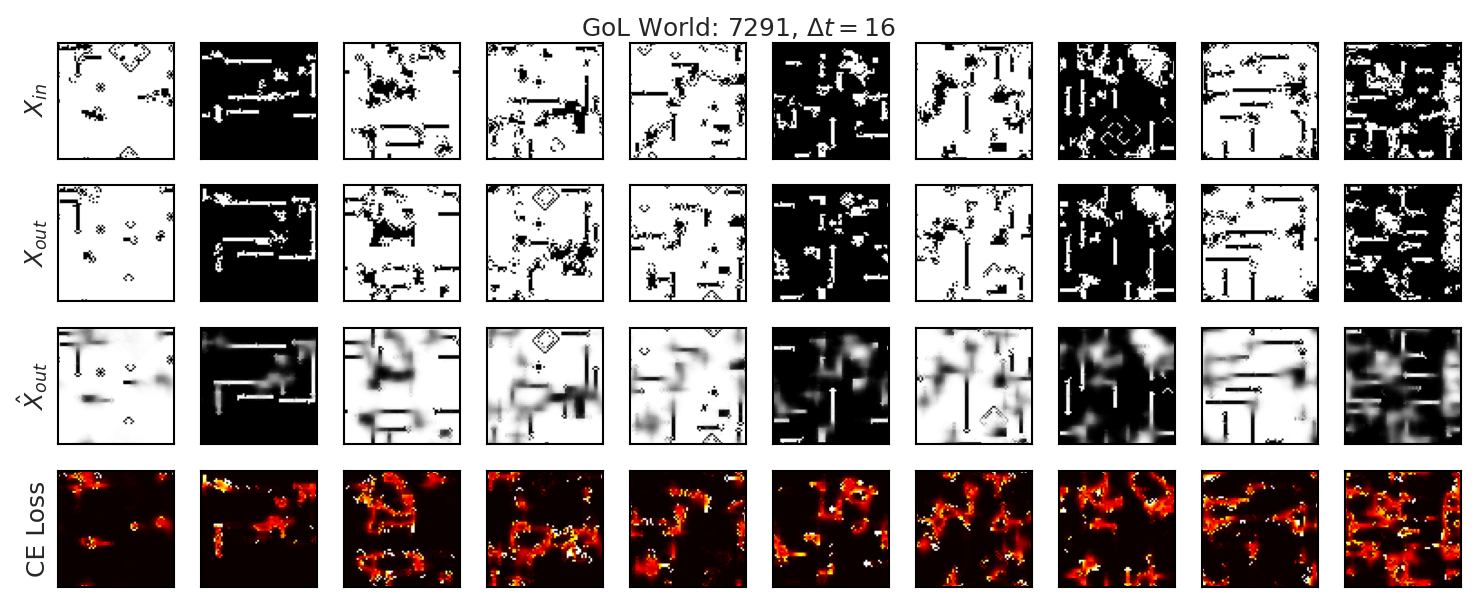

Args(seed=1, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=7787_dt=16_seed=1', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7787, grid_size=64, t_start=32, t_end=64, dt=[16]))


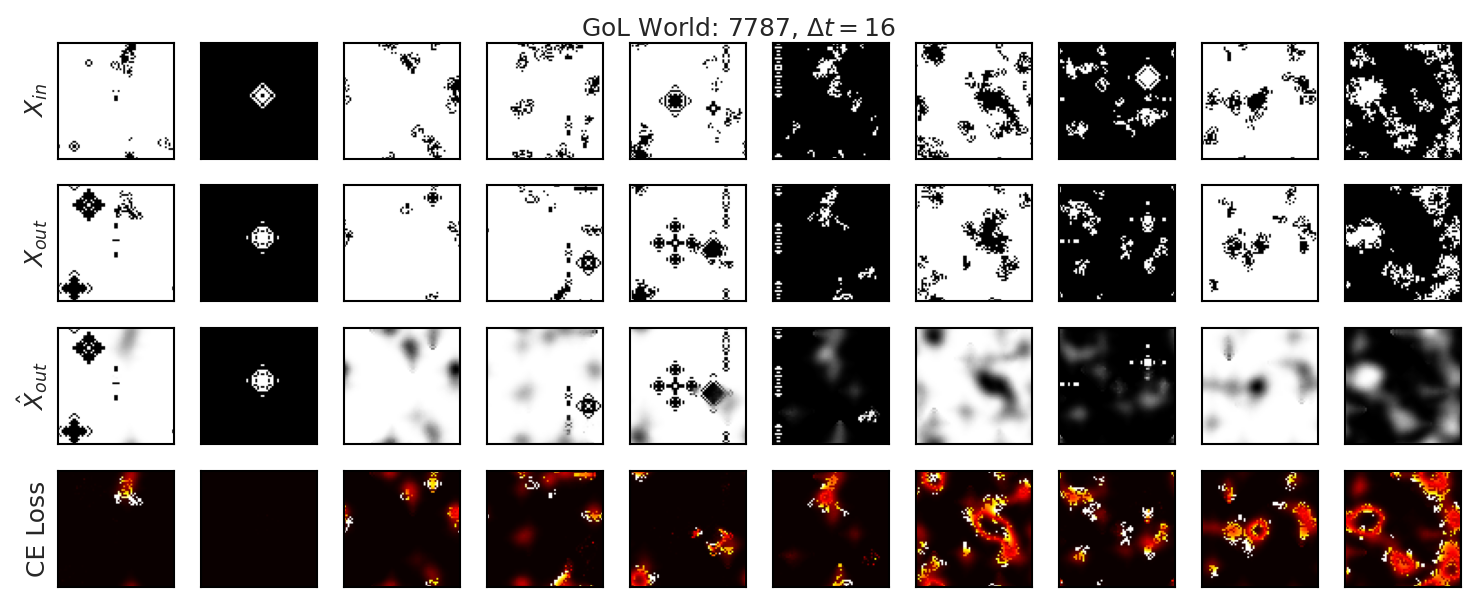

Args(seed=1, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=55871_dt=16_seed=1', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=55871, grid_size=64, t_start=32, t_end=64, dt=[16]))


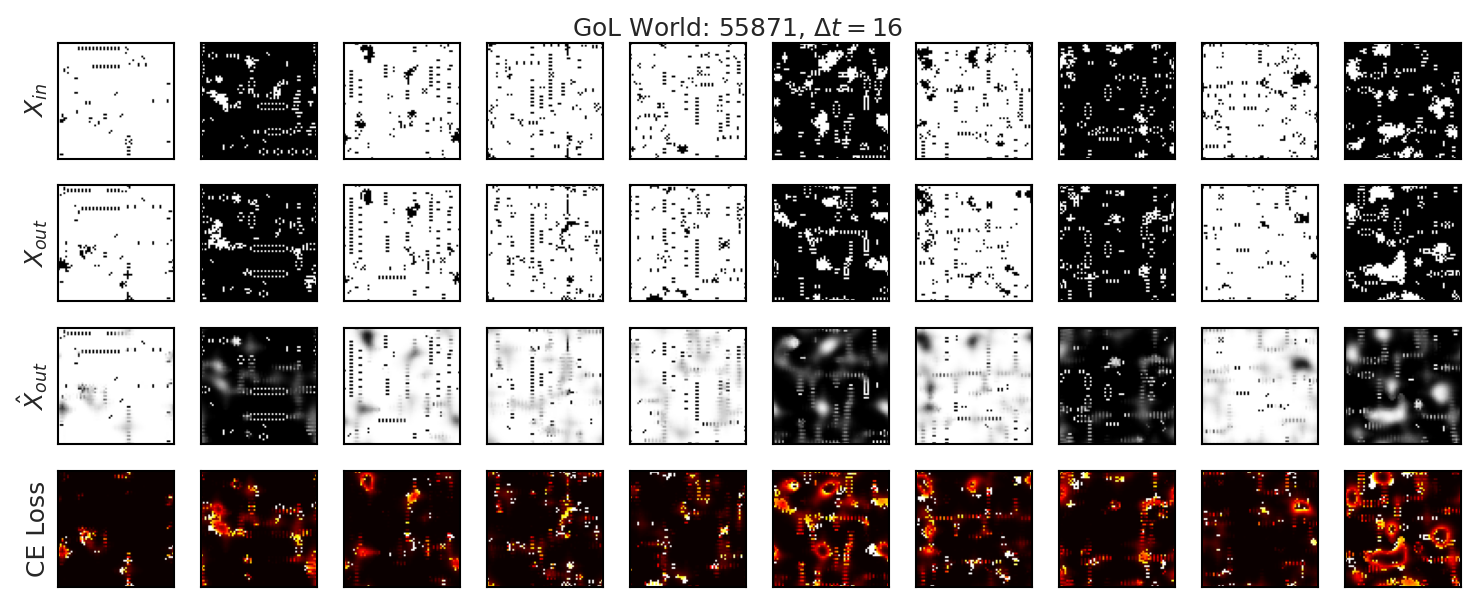

Args(seed=2, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=15923_dt=16_seed=2', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=15923, grid_size=64, t_start=32, t_end=64, dt=[16]))


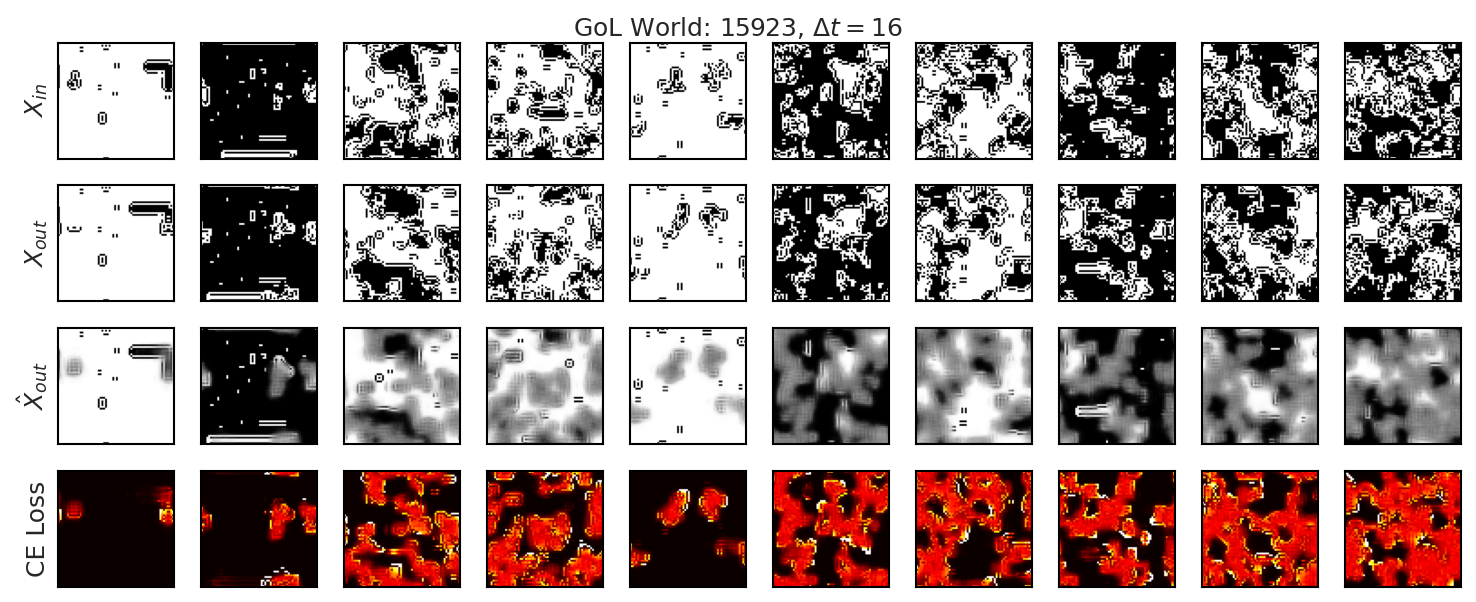

In [48]:
dt = 16
for gol_params in df.gol_params.unique():
    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x0") & (df.dt==dt)]
    idx = a.index[a.final_loss.argmin()]
    lp_args = lp_args_all[idx]
    args = util.load_pkl(lp_args.load_dir, "args")

    from main import Main
    main = Main(args)

    params = util.load_pkl(args.save_dir, "params")
    rng = jax.random.PRNGKey(0)
    batch = main.generate_batch(rng)

    def put_border(ax):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color('black')
        ax.set_xticks([])
        ax.set_yticks([])

    n_samples = 10
    # plt.figure(figsize=(10, 2.5*n_samples))

    fig, axs = plt.subplots(4, n_samples, figsize=(n_samples, 4), dpi=150)
    for i in range(n_samples):
        x0, x1 = batch['x0'], batch['x1']
        loss, metrics = main.loss_fn(params, batch)
        logits = metrics['logits']
        x1_pred = jax.nn.softmax(logits, axis=-1)[..., 1]
        plt.sca(axs[0, i]); plt.imshow(x0[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$X_{in}$", fontsize=12)
        plt.sca(axs[1, i]); plt.imshow(x1[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$X_{out}$", fontsize=12)
        plt.sca(axs[2, i]); plt.imshow(x1_pred[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$\hat{X}_{out}$", fontsize=12)
        plt.sca(axs[3, i]); plt.imshow(metrics['loss_ce'][i], cmap='hot', vmin=0., vmax=2.); put_border(plt.gca())
        if i==0: plt.ylabel("CE Loss", fontsize=12)
    plt.tight_layout()
    plt.suptitle(f"GoL World: {gol_params}, $\Delta t={dt}$", fontsize=12, y=1.)
    plt.show()

In [213]:
args = args_all[4]
net_params = util.load_pkl(args.save_dir, "params")
from main import Main
main = Main(args)

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=16_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[16]))


In [214]:
def init_params(rng, grid_size=64):
    params = {}
    gs = 1
    while gs < grid_size:
        rng, _rng = split(rng)
        params[f'res_{gs:03d}'] = jax.random.normal(_rng, (gs, gs, 2))
        gs = gs * 2
    gs = grid_size
    rng, _rng = split(rng)
    params[f'res_{gs:03d}'] = jax.random.normal(_rng, (gs, gs, 2))
    return params

def get_x0(rng, params, do_augs=True):
    gs = max([v.shape[0] for v in params.values()])
    x0 = jnp.zeros((gs, gs, 2))
    for k, v in params.items():
        x0 = x0 + jax.image.resize(v, (gs, gs, 2), method='bilinear')
    x0 = x0 + jax.random.normal(rng, x0.shape)*.1

    if do_augs:
        rng, _rng = split(rng)
        scale = jax.random.uniform(rng, (2,), minval=0.8, maxval=1.2)
        rng, _rng = split(rng)
        translate = jax.random.uniform(rng, (2,), minval=-gs//5, maxval=gs//5)
        x0 = jax.image.scale_and_translate(x0, (gs, gs, 2), (0, 1), scale, translate, method='bilinear')
    x0 = jax.nn.softmax(x0, axis=-1)
    return x0

def loss_fn(params, rng, i_neuron):
    x0 = jax.vmap(get_x0, in_axes=(0, None))(split(rng, 4), params)
    dt_id = jnp.array(0, dtype=int)
    apply_fn = jax.vmap(partial(main.net.apply, dt_id=dt_id, return_hidden_reprs=True, method=main.net.forward_soft), in_axes=(None, 0))
    logits, hidden_reprs = apply_fn(net_params, x0)
    features = jax.tree.map(lambda x: x.mean(axis=(-3, -2)), hidden_reprs)
    features = jnp.concatenate(features, axis=-1)
    return features[..., i_neuron].mean()

def do_iter(train_state, rng, i_neuron):
    loss, grads = jax.value_and_grad(loss_fn)(train_state.params, rng, i_neuron)
    train_state = train_state.apply_gradients(grads=grads)
    return train_state, loss

@jax.jit
def get_feature_viz(rng, i_neuron):
    params = init_params(rng)

    tx = optax.chain(optax.clip_by_global_norm(1.), optax.adamw(1e-2, weight_decay=0., eps=1e-8))
    train_state = TrainState.create(apply_fn=main.net.apply, params=params, tx=tx)

    do_iter_fn = jax.jit(partial(do_iter, i_neuron=i_neuron))
    train_state, loss_history = jax.lax.scan(do_iter_fn, train_state, split(rng, 2000))
    return train_state.params, loss_history

# for i_neuron in tqdm(list(range(0, 512, 16))):
#     rng = jax.random.PRNGKey(0)
#     params, loss_history = get_feature_viz(rng, i_neuron)

#     plt.figure(figsize=(15, 5))
#     plt.subplot(121); plt.plot(loss_history); plt.ylabel('Loss'); plt.xlabel('Iterations')
#     plt.subplot(122)
#     x0 = get_x0(rng, train_state.params, do_augs=False)
#     plt.imshow(x0[..., 0]); plt.xticks([]); plt.yticks([]); plt.title(f"Image for neuron {i_neuron}")
#     plt.show()

In [215]:
rng = jax.random.PRNGKey(0)
params, loss_history = jax.lax.map(partial(get_feature_viz, rng), jnp.arange(0, 512, 16), batch_size=4)

In [216]:
x0 = jax.vmap(partial(get_x0, do_augs=False), in_axes=(None, 0))(rng, params)
x0 = x0[..., 0]
x0.shape

(32, 64, 64)

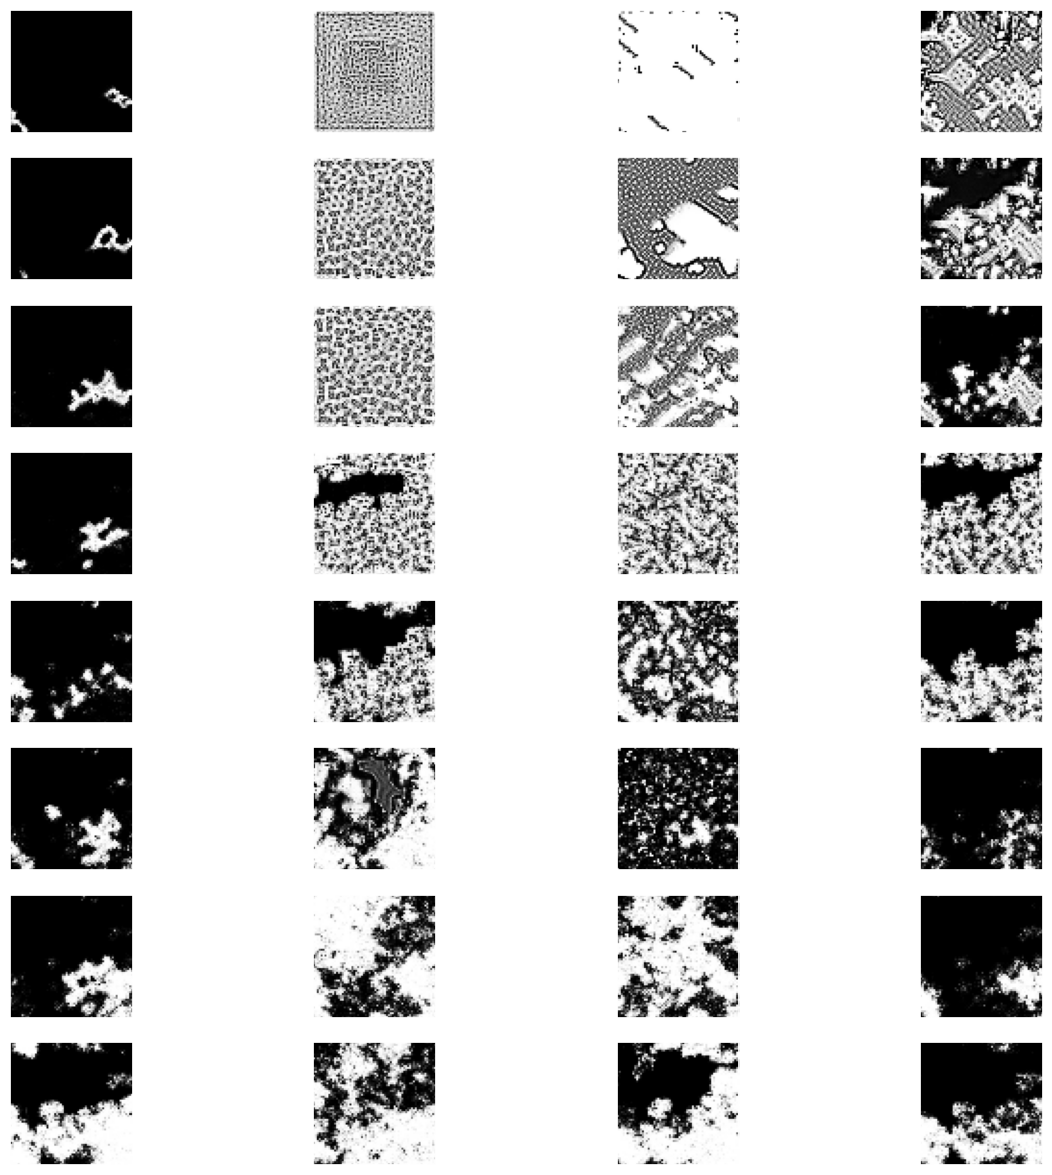

In [217]:
plt.figure(figsize=(15, 15))

iplt = 0
for i in range(8):
    for j in range(4):
        plt.subplot(8, 4, iplt + 1)
        plt.imshow(x0[iplt], cmap='gray', vmin=0, vmax=1.); plt.xticks([]); plt.yticks([])
        iplt += 1
plt.show()

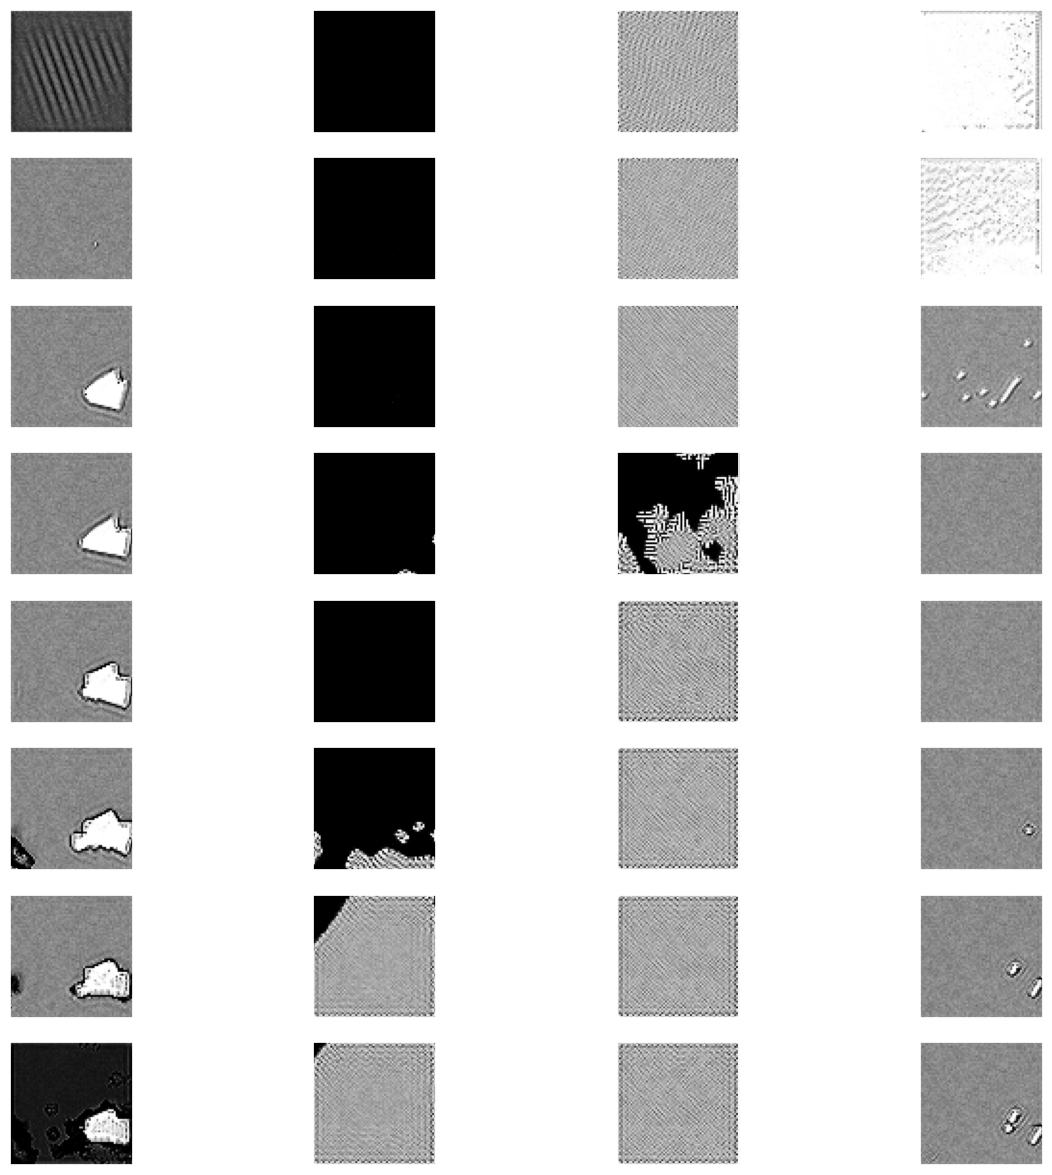

In [212]:
plt.figure(figsize=(15, 15))

iplt = 0
for i in range(8):
    for j in range(4):
        plt.subplot(8, 4, iplt + 1)
        plt.imshow(x0[iplt], cmap='gray', vmin=0, vmax=1.); plt.xticks([]); plt.yticks([])
        iplt += 1
plt.show()